In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from collections import OrderedDict
from torch import nn
from tqdm.auto import tqdm

def load_vicon_hip_moment_data(label_file_name, record_time_sec):
    output_df = pd.read_csv(label_file_name,
                            delimiter=',',
                            skiprows=lambda x: x in range(0, record_time_sec*1000 + 10), # skip force plate data and 10 rows of header
                            encoding_errors='ignore') # Add this line to ignore encoding errors
    output_df = output_df.fillna(0) # fill NaN with 0
    output_buffer = output_df.values[:, [54, 6]]/1000 # 54 for right hip, 6 for left hip, divide by 1000 to convert to Nm
    # output_buffer[:, 1] *= -1 # Flip the sign of left hip moment
    output_buffer[:, 0] *= -1 # Flip the sign of right hip moment to make it Flex. = +

    output_buffer = lowpass_filter(output_buffer, order=4, cutoff_freq=4, sampling_freq=100)
    return output_buffer
def lowpass_filter(data, order=4, cutoff_freq=4, sampling_freq=100):
    nyquist_freq = sampling_freq / 2
    normalized_cutoff_freq = cutoff_freq / nyquist_freq
    b, a = signal.butter(order, normalized_cutoff_freq, btype='low')
    filtered_data = np.zeros_like(data)
    for i in range(0, data.shape[1]):
        filtered_data[:, i] = signal.filtfilt(b, a, data[:, i])
    
    return filtered_data

def load_model(model_dir, epoch=None):
    if epoch is not None:
        model_file = os.path.join(model_dir, model_name + f'_epoch_{epoch}.pt')
    else:
        model_file = os.path.join(model_dir, model_name + '.pt')

    # --- Instantiate the Model ---
    model_instance = TCNModel(hyperparam_config)

    # --- Load the State Dictionary ---
    state_dict = torch.load(model_file, map_location=torch.device('cpu')) # Load to CPU first
    model_instance.load_state_dict(state_dict)

    import datetime
    print(f"Loading model from: {model_file}")
    mod_time_timestamp = os.path.getmtime(model_file)
    mod_time_datetime = datetime.datetime.fromtimestamp(mod_time_timestamp)
    print(f"Model file last modified: {mod_time_datetime}")

    return model_instance
def load_input_n_label(file_dir, model_dir, train_data_proportion=1.0):

    # for trial in os.listdir(file_dir):
    #     trial_path = os.path.join(file_dir, trial)
    #     if not os.path.isdir(trial_path): continue # Skip if not a directory

        # input_file_dir = os.path.join(file_dir, trial, 'Input')
        # label_file_dir = os.path.join(file_dir, trial, 'Label')
        # input_file_names = sorted(os.listdir(input_file_dir))
        # label_file_names = sorted(os.listdir(label_file_dir)) 
    
    input_file_dir = os.path.join(file_dir, 'Input')
    label_file_dir = os.path.join(file_dir, 'Label')
    input_file_names = sorted(os.listdir(input_file_dir))
    label_file_names = sorted(os.listdir(label_file_dir))

    input_imu_file = os.path.join(input_file_dir, input_file_names[0])
    input_motor_file = os.path.join(input_file_dir, input_file_names[1])
    label_file = os.path.join(label_file_dir, label_file_names[0])

    input_mean = np.load(os.path.join(model_dir, 'input_mean.npy'))
    input_std = np.load(os.path.join(model_dir, 'input_std.npy'))
    
    input_imu = pd.read_csv(input_imu_file)
    input_motor = pd.read_csv(input_motor_file)

    # Load only acceleration features (3 features: X, Y, Z)
    input_R_features = input_imu[['Thigh_R_Acc_X', 'Thigh_R_Acc_Y', 'Thigh_R_Acc_Z']].values
    input_L_features = input_imu[['Thigh_L_Acc_X', 'Thigh_L_Acc_Y', 'Thigh_L_Acc_Z']].values
    input_L_features[:, 1] *= -1 # Mirroring: flip Y-axis
    record_time_sec = int(input_R_features.shape[0] / 100) # Assuming 100Hz sampling rate

    # Normalize the input features
    input_R_tensor = torch.tensor((input_R_features - input_mean) / input_std, dtype=torch.float32)
    input_L_tensor = torch.tensor((input_L_features - input_mean) / input_std, dtype=torch.float32)
    
    # Calculate record time based on the length of the input data
    label_R_raw = load_vicon_hip_moment_data(label_file, record_time_sec)[:, 0] # Index 0 for Right Hip Moment
    label_L_raw = load_vicon_hip_moment_data(label_file, record_time_sec)[:, 1] # Index 1 for Left Hip Moment
    print("label shape:", label_R_raw.shape, label_L_raw.shape)

    # Data proportion
    if train_data_proportion < 1.0:
        num_samples = int(len(input_R_features) * train_data_proportion)
        input_R_features = input_R_features[num_samples:]
        input_L_features = input_L_features[num_samples:]
        input_R_tensor = input_R_tensor[num_samples:]
        input_L_tensor = input_L_tensor[num_samples:]
        label_R_raw = label_R_raw[num_samples:]
        label_L_raw = label_L_raw[num_samples:]

    return input_R_features, input_L_features, input_R_tensor, input_L_tensor, label_R_raw, label_L_raw


In [2]:
# Try importing with the full path
from TCN_Header_Model import TCNModel, LSTMModel
import datetime

subject_name = 'AB07_Leo'
speed_condition = '1p2mps'
trial_num = "trial_3"

model_name = 'IDL_AccelOnly'
model_dir = '/home/metamobility2/JiminMM2/IDL Project/Jimin_IDL_AccelOnly/IDL_AccelOnly'

file_dir = '/home/metamobility2/JiminMM2/Dataset/Biotorque_14Subjects/Synced_Biotorque_LG_Data' + '/' + subject_name + '/'+ speed_condition + '/' + trial_num

# Define hyperparam_config directly (instead of importing from TCN_Training to avoid wandb dependency issue)
hyperparam_config = {
    'wandb_project_name': 'Biotorque_LGRARD',
    'wandb_session_name': 'IDL_AccelOnly',
    'input_size': 3,
    'output_size': 1,
    'architecture': 'TCN',
    'transfer_learning': False,
    'dataset_proportion': 1.0,
    'resume_training': True,
    'epochs': 30,
    'batch_size': 32,
    'init_lr': 5e-6,
    'dropout': 0.15,
    'validation_split': 0.1,
    'window_size': 95,
    'number_of_layers': 2,
    'num_channels': [80, 80, 80, 80, 80],
    'kernel_size': 5,
    'dilations': [1, 2, 4, 8, 16],
    'number_of_workers': 10
}


model_instance = load_model(model_dir, epoch=None)
input_R_features, input_L_features, input_R_tensor, input_L_tensor, label_R_raw, label_L_raw = load_input_n_label(file_dir, model_dir, train_data_proportion=1.0)


TCN parameter #:  291120

FCNN parameter #:  7601
Loading model from: /home/metamobility2/JiminMM2/IDL Project/Jimin_IDL_AccelOnly/IDL_AccelOnly/IDL_AccelOnly.pt
Model file last modified: 2026-04-28 19:23:54.344140
label shape: (2900,) (2900,)


/tmp/ipykernel_891849/1342159794.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_file, map_location=torch.device('cpu')) # Load to CPU fir

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Move model to device and set to eval mode
model_instance.to(device)
model_instance.eval()

window_size = hyperparam_config['window_size']
total_length = input_R_tensor.shape[0]
valid_predictions_count = total_length - window_size + 1

# Create array to store all predictions
all_predictions_R = np.zeros(valid_predictions_count)
all_predictions_L = np.zeros(valid_predictions_count)
batch_bar = tqdm(total=valid_predictions_count, dynamic_ncols=True, position=0, leave=False, desc='Processing windows', unit='window')

label_mean = np.load(os.path.join(model_dir, 'label_mean.npy'))
label_std = np.load(os.path.join(model_dir, 'label_std.npy'))

# Perform inference using sliding window approach
with torch.no_grad():  # Disable gradient calculations for inference
    for i in range(valid_predictions_count):
        # Extract window
        window_R = input_R_tensor[i:i+window_size, :]
        window_L = input_L_tensor[i:i+window_size, :]
        
        # Reshape for model: (Batch, Features, Sequence)
        window_batch_R = window_R.unsqueeze(0).transpose(1, 2).to(device)
        window_batch_L = window_L.unsqueeze(0).transpose(1, 2).to(device)
        
        # Get prediction for this window
        pred_normalized_R = model_instance(window_batch_R)
        pred_normalized_L = model_instance(window_batch_L)
        
        # Store denormalized prediction
        pred_value_R = (pred_normalized_R.cpu().numpy() * label_std.item()) + label_mean.item()
        pred_value_L = (pred_normalized_L.cpu().numpy() * label_std.item()) + label_mean.item()
        all_predictions_R[i] = pred_value_R[0, 0]
        all_predictions_L[i] = pred_value_L[0, 0]
        batch_bar.update()

# Create appropriate time axis for predictions
# Predictions start at index (window_size-1) of the original time series
pred_time_axis = np.arange(window_size-1, window_size-1+valid_predictions_count) / 100  # Assuming 100Hz
time_axis = np.arange(0, len(label_R_raw)) / 100  # Assuming 100Hz sampling rate

cuda


Processing windows:   0%|          | 0/2806 [00:00<?, ?window/s]

R - RMSE: 0.0842, R^2: 0.9323
Saved SVG: /home/metamobility2/JiminMM2/IDL Project/TCN_AccelOnly_R_HipMoment.svg


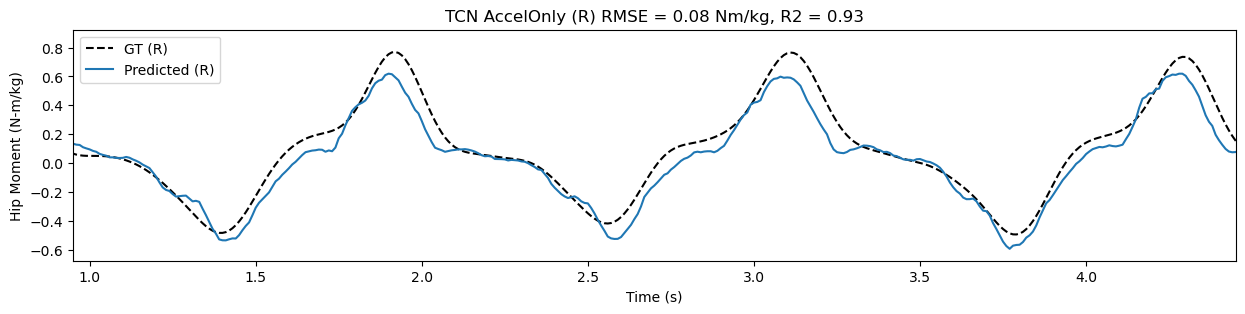

L - RMSE: 0.0866, R^2: 0.9106
Saved SVG: /home/metamobility2/JiminMM2/IDL Project/TCN_AccelOnly_L_HipMoment.svg


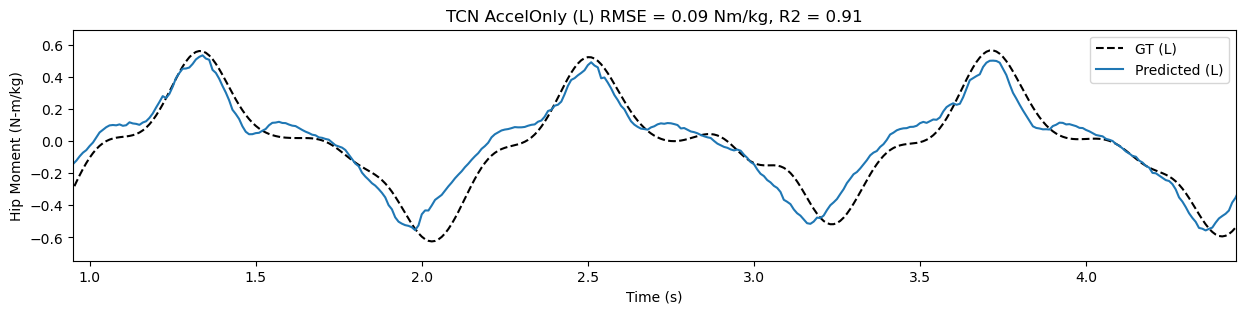

In [4]:
def plot_and_metrics_single_leg(pred_time_axis, label_raw, predictions, leg_label):
    # Plot
    # Metrics
    overlap_length = min(len(predictions), len(label_raw[window_size-1:]))
    ground_truth = label_raw[window_size-1:window_size-1+overlap_length]
    preds = predictions[:overlap_length]
    rmse = np.sqrt(np.mean((ground_truth - preds) ** 2))
    ss_res = np.sum((ground_truth - preds) ** 2)
    ss_tot = np.sum((ground_truth - np.mean(ground_truth)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    print(f"{leg_label} - RMSE: {rmse:.4f}, R^2: {r2:.4f}")
    
    plt.figure(figsize=(15, 3))
    plt.plot(time_axis, label_raw, label=f'GT ({leg_label})', linestyle='--', color = "black")
    plt.plot(pred_time_axis, predictions, label=f'Predicted ({leg_label})')
    plt.xlabel('Time (s)')
    plt.xlim(0.95, 0.95+3.5)
    plt.ylabel('Hip Moment (N-m/kg)')
    plt.legend()
    # plt.grid(True)
    plt.title(f'TCN AccelOnly ({leg_label}) RMSE = {rmse:.2f} Nm/kg, R2 = {r2:.2f}')
    
    save_dir = r"/home/metamobility2/JiminMM2/IDL Project"
    
    # SVG export
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"TCN_AccelOnly_{leg_label}_HipMoment.svg")
    else:
        save_path = f"TCN_AccelOnly_{leg_label}_HipMoment.svg"

    plt.savefig(
        save_path,
        format='svg',
        bbox_inches='tight'
    )

    print(f"Saved SVG: {save_path}")
    
    
    plt.show()


# 오른쪽 다리
plot_and_metrics_single_leg(pred_time_axis, label_R_raw, all_predictions_R, 'R')

# 왼쪽 다리
plot_and_metrics_single_leg(pred_time_axis, label_L_raw, all_predictions_L, 'L')
